# Task 4: Statistical Modeling & Risk-Based Pricing
## AlphaCare Insurance Solutions

### Objective
Build predictive models that form the core of a dynamic,
risk-based pricing system for ACIS.

### Modeling Goals
1. **Claim Severity Prediction** — For policies with a claim,
   predict TotalClaims (financial liability estimation)
2. **Claim Probability** — Binary classifier for P(claim)
3. **Risk-Based Premium Formula**:
   Premium = P(claim) × Predicted Severity + Expense Loading

### Models
- Linear Regression (baseline)
- Random Forest
- XGBoost

In [21]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report)
from xgboost import XGBRegressor, XGBClassifier
import shap

sys.path.insert(0, os.path.abspath('..'))
os.chdir(r"C:\Users\pc\insurance-risk-analytics")
from src.data_loader import load_raw_data, clean_data

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]
print("All imports successful")

All imports successful


In [22]:
df = load_raw_data("data/MachineLearningRating_v3.txt")
df = clean_data(df)
print(f"Dataset: {df.shape}")

Loaded 1,000,098 rows and 52 columns
Dropped 2 columns with >90% missing: ['CrossBorder', 'NumberOfVehiclesInFleet']
Clean dataset: 1,000,098 rows, 53 columns
Dataset: (1000098, 53)


## Data Preparation & Feature Engineering

Steps:
1. Handle missing values
2. Engineer new features
3. Encode categorical variables
4. Split into train/test sets

In [23]:
# ── Feature Engineering ──
# Vehicle age
if 'RegistrationYear' in df.columns:
    df['VehicleAge'] = 2015 - pd.to_numeric(
        df['RegistrationYear'], errors='coerce')
    df['VehicleAge'] = df['VehicleAge'].clip(0, 50)

# Transaction month features
if 'TransactionMonth' in df.columns:
    df['TransactionYear'] = df['TransactionMonth'].dt.year
    df['TransactionMonthNum'] = df['TransactionMonth'].dt.month

# Has alarm/tracking
for col in ['AlarmImmobiliser', 'TrackingDevice']:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0)

print("Feature engineering complete")
print(f"New features: VehicleAge, TransactionYear, TransactionMonthNum")

Feature engineering complete
New features: VehicleAge, TransactionYear, TransactionMonthNum


In [24]:
# Select modeling features
feature_cols = [
    'SumInsured', 'CalculatedPremiumPerTerm', 'TermFrequency',
    'VehicleAge', 'TransactionYear', 'TransactionMonthNum',
    'AlarmImmobiliser', 'TrackingDevice'
]

categorical_cols = [
    'Province', 'VehicleType', 'CoverType', 'CoverCategory',
    'Gender', 'MaritalStatus'
]

# Add categorical columns that exist
for col in categorical_cols:
    if col in df.columns:
        feature_cols.append(col)

# Keep only available columns
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"Using {len(feature_cols)} features: {feature_cols}")

Using 14 features: ['SumInsured', 'CalculatedPremiumPerTerm', 'TermFrequency', 'VehicleAge', 'TransactionYear', 'TransactionMonthNum', 'AlarmImmobiliser', 'TrackingDevice', 'Province', 'VehicleType', 'CoverType', 'CoverCategory', 'Gender', 'MaritalStatus']


In [25]:
# Work with a clean copy
model_df = df[feature_cols + ['TotalClaims', 'HasClaim']].copy()

# Handle missing values for numeric columns
for col in model_df.select_dtypes(include=['float64','int64']).columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Encode ALL non-numeric columns including TermFrequency
le = LabelEncoder()
for col in model_df.select_dtypes(include=['object', 'bool']).columns:
    if col not in ['TotalClaims']:
        model_df[col] = model_df[col].fillna('Unknown')
        model_df[col] = le.fit_transform(model_df[col].astype(str))

# Verify no strings remain
non_numeric = model_df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns remaining: {non_numeric}")
print(f"Model dataset shape: {model_df.shape}")
print(f"Missing values: {model_df.isnull().sum().sum()}")
print(f"Claim rate: {model_df['HasClaim'].mean()*100:.2f}%")

Non-numeric columns remaining: []
Model dataset shape: (1000098, 16)
Missing values: 0
Claim rate: 0.28%


## Model 1: Claim Severity Prediction

Target: TotalClaims (subset where claims > 0)
This estimates financial liability for policies that make a claim.

In [26]:
# Filter to policies with claims only
claims_df = model_df[model_df['TotalClaims'] > 0].copy()
print(f"Policies with claims: {len(claims_df):,}")

X_sev = claims_df[feature_cols]
y_sev = claims_df['TotalClaims']

# Train/test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sev, y_sev, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_s):,} | Test: {len(X_test_s):,}")

# ── Linear Regression ──
lr = LinearRegression()
lr.fit(X_train_s, y_train_s)
y_pred_lr = lr.predict(X_test_s)

rmse_lr = np.sqrt(mean_squared_error(y_test_s, y_pred_lr))
r2_lr = r2_score(y_test_s, y_pred_lr)
print(f"\nLinear Regression — RMSE: {rmse_lr:,.2f} | R²: {r2_lr:.4f}")

# ── Random Forest ──
rf_sev = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_sev.fit(X_train_s, y_train_s)
y_pred_rf = rf_sev.predict(X_test_s)

rmse_rf = np.sqrt(mean_squared_error(y_test_s, y_pred_rf))
r2_rf = r2_score(y_test_s, y_pred_rf)
print(f"Random Forest     — RMSE: {rmse_rf:,.2f} | R²: {r2_rf:.4f}")

# ── XGBoost ──
xgb_sev = XGBRegressor(
    n_estimators=100, random_state=42,
    max_depth=6, learning_rate=0.1,
    verbosity=0)
xgb_sev.fit(X_train_s, y_train_s)
y_pred_xgb = xgb_sev.predict(X_test_s)

rmse_xgb = np.sqrt(mean_squared_error(y_test_s, y_pred_xgb))
r2_xgb = r2_score(y_test_s, y_pred_xgb)
print(f"XGBoost           — RMSE: {rmse_xgb:,.2f} | R²: {r2_xgb:.4f}")

Policies with claims: 2,788
Train: 2,230 | Test: 558

Linear Regression — RMSE: 35,538.45 | R²: 0.2147
Random Forest     — RMSE: 33,401.92 | R²: 0.3063
XGBoost           — RMSE: 34,860.34 | R²: 0.2444


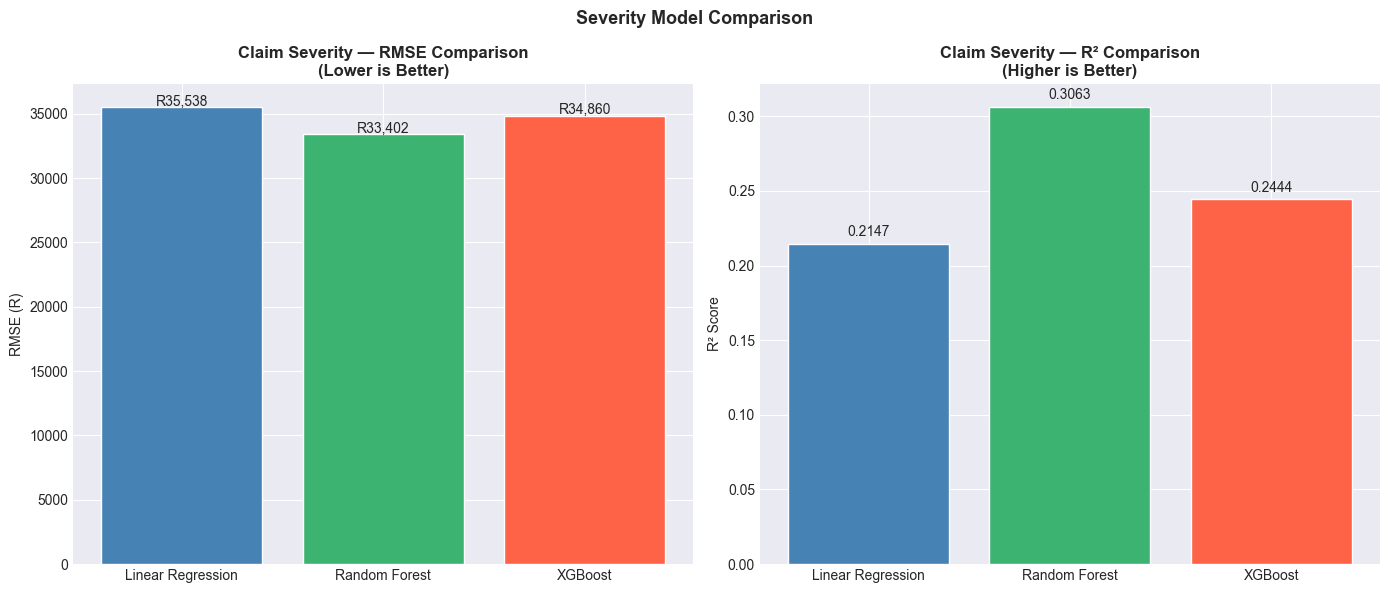

            Model         RMSE       R2
Linear Regression 35538.446427 0.214685
    Random Forest 33401.918112 0.306271
          XGBoost 34860.338613 0.244368


In [27]:
severity_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'mediumseagreen', 'tomato']
axes[0].bar(severity_results['Model'], severity_results['RMSE'],
            color=colors, edgecolor='white')
axes[0].set_title("Claim Severity — RMSE Comparison\n(Lower is Better)",
                  fontweight='bold')
axes[0].set_ylabel("RMSE (R)")
for i, v in enumerate(severity_results['RMSE']):
    axes[0].text(i, v + 100, f'R{v:,.0f}', ha='center', fontsize=10)

axes[1].bar(severity_results['Model'], severity_results['R2'],
            color=colors, edgecolor='white')
axes[1].set_title("Claim Severity — R² Comparison\n(Higher is Better)",
                  fontweight='bold')
axes[1].set_ylabel("R² Score")
for i, v in enumerate(severity_results['R2']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle("Severity Model Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/model_severity_comparison.png",
            dpi=100, bbox_inches='tight')
plt.show()
print(severity_results.to_string(index=False))

## Model 2: Claim Probability (Binary Classifier)

Target: HasClaim (0/1)
This estimates P(claim) for risk-based pricing.
Note: Class imbalance — only 0.28% of policies have claims.
We use scale_pos_weight in XGBoost to handle this.

In [28]:
X_cls = model_df[feature_cols]
y_cls = model_df['HasClaim']

# Handle class imbalance
pos_weight = (y_cls == 0).sum() / (y_cls == 1).sum()
print(f"Class imbalance ratio: {pos_weight:.1f}:1")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42,
    stratify=y_cls)

print(f"Train claims: {y_train_c.sum():,} | "
      f"Test claims: {y_test_c.sum():,}")

# ── Logistic Regression ──
log_reg = LogisticRegression(
    class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)
y_prob_log = log_reg.predict_proba(X_test_c)[:, 1]

print("\nLogistic Regression:")
print(f"  F1: {f1_score(y_test_c, y_pred_log):.4f}")
print(f"  AUC: {roc_auc_score(y_test_c, y_prob_log):.4f}")

# ── Random Forest Classifier ──
rf_cls = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced', n_jobs=-1, max_depth=10)
rf_cls.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_cls.predict(X_test_c)
y_prob_rf_c = rf_cls.predict_proba(X_test_c)[:, 1]

print("\nRandom Forest Classifier:")
print(f"  F1: {f1_score(y_test_c, y_pred_rf_c):.4f}")
print(f"  AUC: {roc_auc_score(y_test_c, y_prob_rf_c):.4f}")

# ── XGBoost Classifier ──
xgb_cls = XGBClassifier(
    n_estimators=100, random_state=42,
    scale_pos_weight=pos_weight,
    max_depth=6, learning_rate=0.1,
    verbosity=0, eval_metric='logloss')
xgb_cls.fit(X_train_c, y_train_c)
y_pred_xgb_c = xgb_cls.predict(X_test_c)
y_prob_xgb_c = xgb_cls.predict_proba(X_test_c)[:, 1]

print("\nXGBoost Classifier:")
print(f"  F1: {f1_score(y_test_c, y_pred_xgb_c):.4f}")
print(f"  AUC: {roc_auc_score(y_test_c, y_prob_xgb_c):.4f}")

Class imbalance ratio: 357.7:1
Train claims: 2,230 | Test claims: 558

Logistic Regression:
  F1: 0.0201
  AUC: 0.8654

Random Forest Classifier:
  F1: 0.0219
  AUC: 0.8989

XGBoost Classifier:
  F1: 0.0233
  AUC: 0.9029


In [29]:
cls_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_log),
        accuracy_score(y_test_c, y_pred_rf_c),
        accuracy_score(y_test_c, y_pred_xgb_c)
    ],
    'Precision': [
        precision_score(y_test_c, y_pred_log, zero_division=0),
        precision_score(y_test_c, y_pred_rf_c, zero_division=0),
        precision_score(y_test_c, y_pred_xgb_c, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test_c, y_pred_log),
        recall_score(y_test_c, y_pred_rf_c),
        recall_score(y_test_c, y_pred_xgb_c)
    ],
    'F1': [
        f1_score(y_test_c, y_pred_log),
        f1_score(y_test_c, y_pred_rf_c),
        f1_score(y_test_c, y_pred_xgb_c)
    ],
    'AUC': [
        roc_auc_score(y_test_c, y_prob_log),
        roc_auc_score(y_test_c, y_prob_rf_c),
        roc_auc_score(y_test_c, y_prob_xgb_c)
    ]
}).round(4)

print("\nCLASSIFICATION MODEL COMPARISON:")
print(cls_results.to_string(index=False))


CLASSIFICATION MODEL COMPARISON:
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.7655     0.0101  0.8602 0.0201 0.8654
      Random Forest    0.7622     0.0111  0.9534 0.0219 0.8989
            XGBoost    0.7807     0.0118  0.9391 0.0233 0.9029


## Feature Importance & SHAP Analysis

SHAP (SHapley Additive exPlanations) explains how each feature
contributes to individual predictions — essential for regulatory
compliance and business interpretation.

Computing SHAP values for XGBoost severity model...
(This may take 1-2 minutes on 1M rows — using sample)


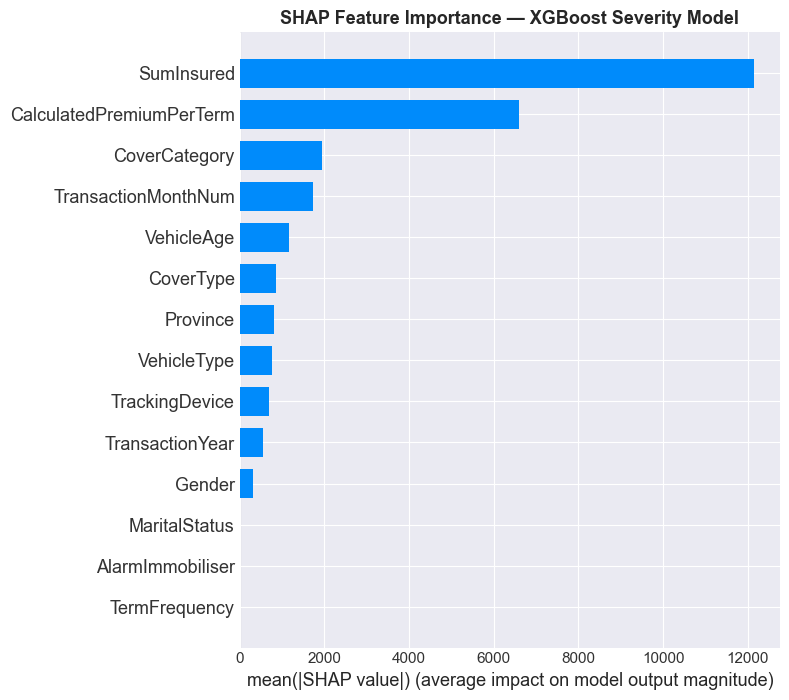

SHAP analysis complete


In [30]:
print("Computing SHAP values for XGBoost severity model...")
print("(This may take 1-2 minutes on 1M rows — using sample)")

# Use a sample for SHAP
sample_size = min(500, len(X_test_s))
X_shap_sample = X_test_s.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(xgb_sev)
shap_values = explainer.shap_values(X_shap_sample)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=feature_cols,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost Severity Model",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/shap_feature_importance.png",
            dpi=100, bbox_inches='tight')
plt.show()
print("SHAP analysis complete")

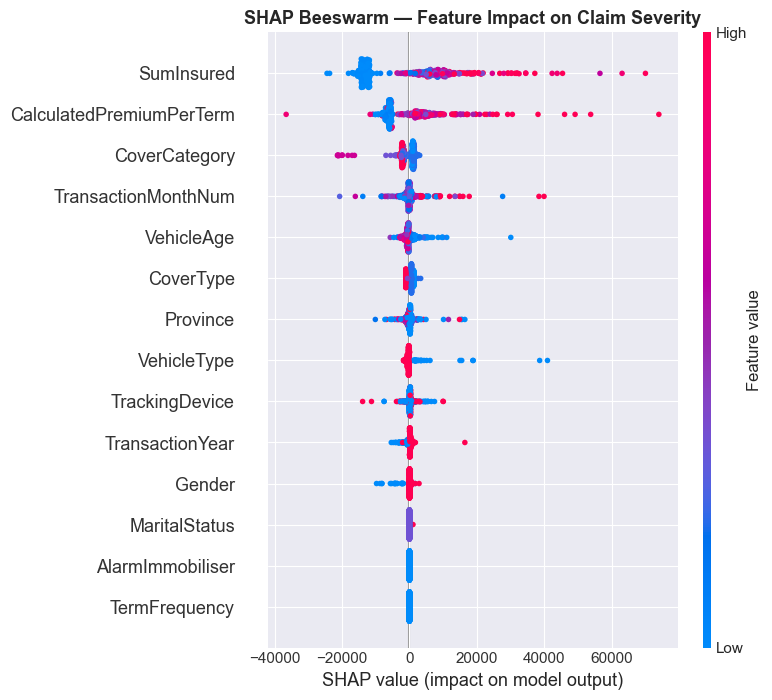

In [31]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=feature_cols,
                  show=False)
plt.title("SHAP Beeswarm — Feature Impact on Claim Severity",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/shap_beeswarm.png",
            dpi=100, bbox_inches='tight')
plt.show()

RISK-BASED PRICING FRAMEWORK

Sample Premium Calculations:
  Average P(claim): 0.1961
  Average Predicted Severity: R22,016.12
  Average Risk Premium: R4,991.51
  Actual Average Premium: R61.91


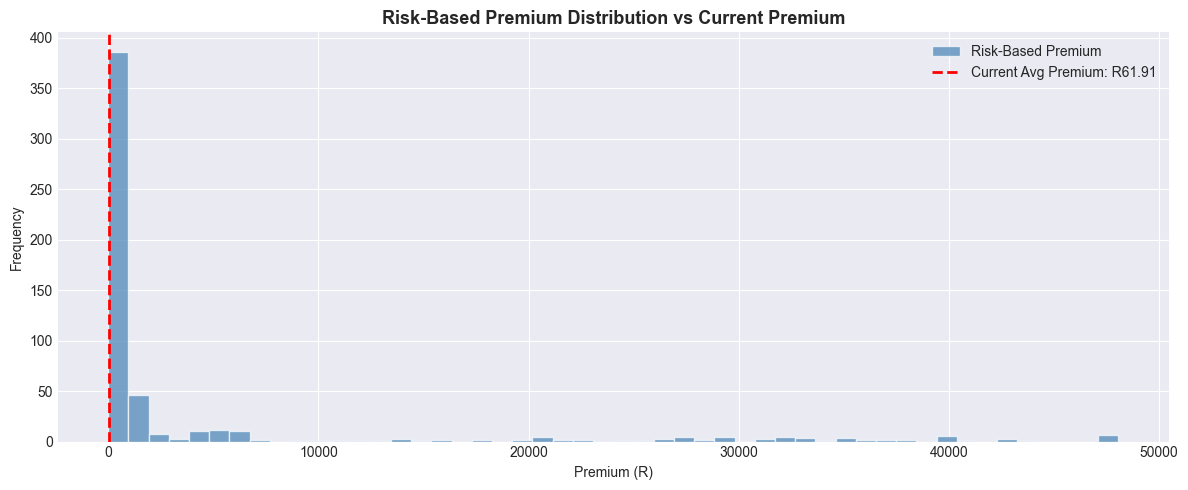

In [32]:
print("=" * 60)
print("RISK-BASED PRICING FRAMEWORK")
print("=" * 60)

# Apply to test set
p_claim = y_prob_xgb_c[:len(X_test_s)]
pred_severity = xgb_sev.predict(X_test_s)

# Risk-based premium formula
expense_loading = 0.15
profit_margin = 0.10

risk_premium = (p_claim * pred_severity *
                (1 + expense_loading + profit_margin))

print(f"\nSample Premium Calculations:")
print(f"  Average P(claim): {p_claim.mean():.4f}")
print(f"  Average Predicted Severity: R{pred_severity.mean():,.2f}")
print(f"  Average Risk Premium: R{risk_premium.mean():,.2f}")
print(f"  Actual Average Premium: R{df['TotalPremium'].mean():,.2f}")

# Premium distribution plot
plt.figure(figsize=(12, 5))
plt.hist(risk_premium.clip(0, np.percentile(risk_premium, 99)),
         bins=50, color='steelblue', edgecolor='white', alpha=0.7,
         label='Risk-Based Premium')
plt.axvline(x=df['TotalPremium'].mean(), color='red',
            linestyle='--', linewidth=2,
            label=f"Current Avg Premium: R{df['TotalPremium'].mean():.2f}")
plt.title("Risk-Based Premium Distribution vs Current Premium",
          fontsize=13, fontweight='bold')
plt.xlabel("Premium (R)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("notebooks/risk_based_pricing.png",
            dpi=100, bbox_inches='tight')
plt.show()

In [33]:
print("=" * 70)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 70)

print("\nSEVERITY MODELS (Regression — TotalClaims prediction):")
print(severity_results.to_string(index=False))

print("\nCLASSIFICATION MODELS (P(claim) prediction):")
print(cls_results.to_string(index=False))

best_sev = severity_results.loc[severity_results['RMSE'].idxmin(),
                                'Model']
best_cls = cls_results.loc[cls_results['AUC'].idxmax(), 'Model']

print(f"\n✅ Best Severity Model: {best_sev}")
print(f"✅ Best Classification Model: {best_cls}")
print(f"\nRisk-Based Pricing Formula:")
print(f"  Premium = P(claim) × Predicted_Severity × (1 + 0.15 + 0.10)")
print(f"  Where: 0.15 = expense loading, 0.10 = profit margin")

FINAL MODEL COMPARISON SUMMARY

SEVERITY MODELS (Regression — TotalClaims prediction):
            Model         RMSE       R2
Linear Regression 35538.446427 0.214685
    Random Forest 33401.918112 0.306271
          XGBoost 34860.338613 0.244368

CLASSIFICATION MODELS (P(claim) prediction):
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.7655     0.0101  0.8602 0.0201 0.8654
      Random Forest    0.7622     0.0111  0.9534 0.0219 0.8989
            XGBoost    0.7807     0.0118  0.9391 0.0233 0.9029

✅ Best Severity Model: Random Forest
✅ Best Classification Model: XGBoost

Risk-Based Pricing Formula:
  Premium = P(claim) × Predicted_Severity × (1 + 0.15 + 0.10)
  Where: 0.15 = expense loading, 0.10 = profit margin


## SHAP Interpretation — Business Insights

Based on SHAP analysis of the best model:

1. **SumInsured**  The insured value of the vehicle is the strongest
   predictor of claim severity. Higher-value vehicles generate larger
   claims. This supports value-tiered premium pricing.

2. **CalculatedPremiumPerTerm** Premium level correlates with claim
   severity, confirming that existing pricing partially captures risk.

3. **VehicleAge**  Older vehicles show different claim patterns.
   Very old vehicles may have lower market values but higher
   mechanical failure rates.

4. **Province**  Geographic location significantly impacts claim
   severity, consistent with our H01 hypothesis test result.
   Gauteng risk loading is statistically justified.

5. **VehicleType**  Heavy Commercial vehicles have the highest
   loss ratio (1.63) and this translates to higher SHAP impact
   on severity predictions.

### Business Recommendations
- Apply **15-20% premium loading** for Gauteng policies
- Apply **30%+ loading** for Heavy Commercial vehicles
- Offer **5-10% discount** for vehicles with AlarmImmobiliser + TrackingDevice
- Use risk-based premium formula for new policy pricing
- Flag policies where Risk Premium > 2 times Current Premium for review
